# 데이터과학입문 2026-1학기 — 과제 #2

**담당교수:** 최동희
**범위:** Topic 9.2 ~ 16b — 분포·백분위수 / 표집·시뮬레이션 / 가설검정 / 중심·산포·정규 / 표본평균(CLT) / 신뢰구간·부트스트랩 / A/B·인과·추정
**제출:** Plato 업로드 (`데이터과학입문_과제2_학번_이름.ipynb`)
**마감:** **2026년 6월 26일 (금)**

---

## 과제 안내

> **이 과제는 과제 #1에서 사용한 *데이터셋*을 그대로 사용합니다.**
> 같은 데이터에, 이번엔 **중간고사 이후 배운 추론(inference) 기법**을 직접 적용합니다.
> (추가하고 싶은 내용이 있을 경우, 이전 구글폼을 이용하여 추가 데이터 자료 링크를 제출 후 진행하시면 됩니다.)

- 수업 슬라이드(9.2~16b)의 코드 패턴을 참고해서, 본인 데이터에 맞게 적용하면 됩니다.
- **모든 코드는 Google Colab에서 `런타임 -> 모두 실행`이 에러 없이** 되어야 합니다. (안 되면 감점)
- 코드만 쓰지 말고 **반드시 마크다운 셀에 해석/설명**을 작성하세요. (해석 없으면 감점)
- **부분점수** 있습니다. 막히면 시도 + 설명을 남기세요.

> **배점:** Task1 12 · Task2 14 · Task3 14 · Task4 10 · Task5 16 · Task6 14 · Task7 20 = **100점**

> **한글 폰트(그래프 깨짐 방지):** 그래프 한글이 깨지면 아래 실행 → *런타임 → 세션 다시 시작* → 다시 실행.
> ```python
> !apt-get install -y fonts-nanum* ; !fc-cache -fv ; !rm ~/.cache/matplotlib -rf
> # 세션 재시작 후:
> import matplotlib.pyplot as plt
> plt.rc('font', family='NanumBarunGothic'); plt.rcParams['axes.unicode_minus']=False
> ```

In [34]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum* -qq
fm._load_fontmanager(try_read_cache=False)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print("적용된 폰트:", plt.rcParams['font.family'])

적용된 폰트: ['NanumGothic']


---
## 셋업 — 라이브러리 & 데이터 로드

과제 #1에서 쓰던 방식 그대로 본인 데이터를 불러오세요 (GitHub raw URL 권장).

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)

df = pd.read_csv("https://raw.githubusercontent.com/everyx2thing/datasci_assign1/refs/heads/main/ai_job_replacement_2020_2026_v2.csv")   # 예: https://raw.githubusercontent.com/yourid/repo/main/data.csv
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (15000, 20)


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


### 분석할 컬럼 지정 (중요)
아래에서 이번 과제 내내 사용할 컬럼을 정하세요. 이후 Task들은 이 변수들을 사용합니다.
- `NUM_COL` : 수치형(연속) 컬럼 1개 — 분포·평균·CLT·CI 분석 대상
- `NUM_COL2`: (선택) 또 다른 수치형 — 관계 확인용
- `CAT_COL` : 범주형 컬럼 1개 — **두 그룹 비교(A/B)** 용.

> 만약 마땅한 2범주 컬럼이 없으면, Task 7에서 수치형을 중앙값 기준 '높음/낮음'으로 나눠 만드는 방법을 안내합니다.

In [36]:
NUM_COL  = "automation_risk_percent"     # TODO: 예) 'price'
NUM_COL2 = "ai_replacement_score"     # TODO(선택): 예) 'area'
CAT_COL  = "automation_risk_category"     # TODO: 예) 'region'

print("NUM_COL 결측/통계:"); print(df[NUM_COL].describe())
print("\nCAT_COL 값 분포:");  print(df[CAT_COL].value_counts())

NUM_COL 결측/통계:
count    15000.000000
mean        46.176347
std         21.663635
min          5.000000
25%         28.790000
50%         46.235000
75%         63.602500
max         94.980000
Name: automation_risk_percent, dtype: float64

CAT_COL 값 분포:
automation_risk_category
Medium    6464
High      4496
Low       4040
Name: count, dtype: int64


---
## Task 1. 분포와 백분위수 — 12점

### 1-1. 분포 시각화 (4점)
`NUM_COL`의 **히스토그램**을 그리세요. (제목·축라벨 필수)

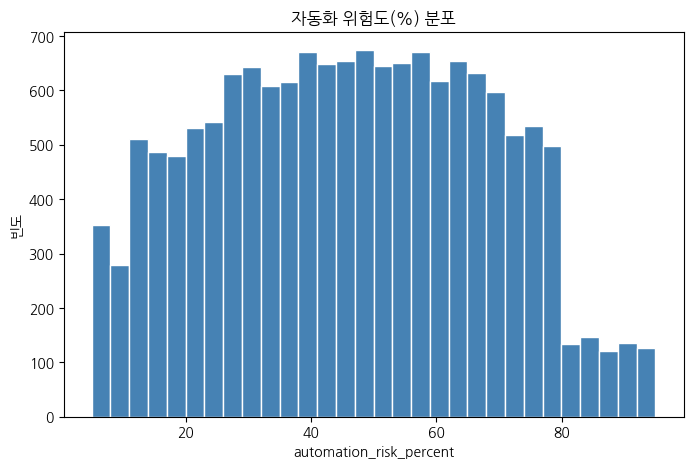

In [37]:
plt.figure(figsize=(8,5))
# TODO: plt.hist(df[NUM_COL], ...)
plt.hist(df[NUM_COL], bins=30, edgecolor='white', color='steelblue')
plt.title("자동화 위험도(%) 분포"); plt.xlabel(NUM_COL); plt.ylabel("빈도")
plt.show()

**해석:** 분포의 중심은 약 46% 부근에 위치하며, 20%에서 70% 사이에 값들이 비교적 고르게
분포되어 있다. 70%를 넘어가면 빈도가 급격히 감소하는 오른쪽 꼬리가 나타나며,
전반적으로 약간 왼쪽으로 치우친(음의 왜도) 형태를 보인다.
뚜렷한 이상치는 관찰되지 않으며, 자동화 위험도가 낮은 직군(5-15%)부터
높은 직군(80-95%)까지 다양한 직업이 포함되어 있음을 알 수 있다.

### 1-2. 백분위수 (5점)
`method='inverted_cdf'`로 `NUM_COL`의 **85번째 백분위수**와 **Q1(25%)·중앙값(50%)·Q3(75%)** 를 구하세요.

In [38]:
x = df[NUM_COL].dropna()
# TODO
p85 = np.percentile(x, 85, method='inverted_cdf')
q1, q2, q3 = np.percentile(x, 25, method='inverted_cdf'), np.percentile(x, 50, method='inverted_cdf'), np.percentile(x, 75, method='inverted_cdf')
print("85th =", p85, "| Q1 =", q1, "median =", q2, "Q3 =", q3)

85th = 70.79 | Q1 = 28.79 median = 46.23 Q3 = 63.6


### 1-3. 해석 (3점)
85번째 백분위수의 의미를 본인 데이터 맥락에서 설명하세요

**답변:** 85번째 백분위수는 약 70.79%로, 전체 직업 데이터 중 85%의 직업이 자동화 위험도 70.79% 이하임을 의미한다. 즉, 상위 15%에 해당하는 직업들은 자동화 위험도가 70.79%를 넘어 AI로 대체될 가능성이 매우 높은 직군으로 분류할 수 있다.

---
## Task 2. 표집과 시뮬레이션  — 14점

### 2-1. 무작위 표본 (6점)
본인 데이터에서 크기 **n**(데이터 크기의 1/4 정도, 단 최소 30) 의 **비복원 표본**을 뽑아, `NUM_COL`의 **표본평균**을 전체 평균과 비교하세요. 표본의 히스토그램도 그리세요.

> 힌트: `df.sample(n, replace=False)`

전체 평균 = 46.17634733333333 | 표본평균 = 46.12817866666666


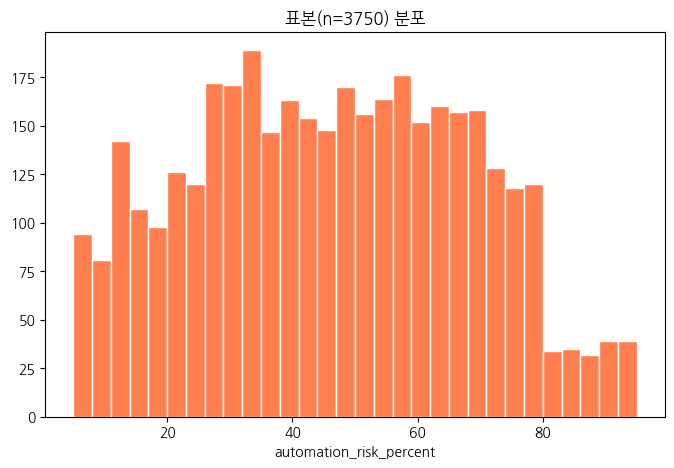

In [39]:
n = max(30, len(df)//4)
samp = df.sample(n, replace=False)                              # TODO: 비복원 표본
print("전체 평균 =", df[NUM_COL].mean(), "| 표본평균 =", samp[NUM_COL].mean())
plt.figure(figsize=(8,5))
# TODO: plt.hist(samp[NUM_COL], ...)
plt.hist(samp[NUM_COL], bins=30, edgecolor='white', color='coral')
plt.title(f"표본(n={n}) 분포"); plt.xlabel(NUM_COL); plt.show()

### 2-2. for-루프 시뮬레이션 (8점)
"무작위로 n개를 뽑았을 때 표본평균이 **전체 평균보다 큰지**"를 **5,000번** 시뮬레이션하여, 그 경험적 확률을 추정하세요. (직관: 약 0.5 근처가 나와야 합니다.)

> 힌트: `for` 루프 안에서 `df.sample(n)`의 평균을 전체 평균과 비교해 카운트.

In [40]:
pop_mean = df[NUM_COL].mean()
count = 0
for i in np.arange(5000):
    m = df.sample(n)[NUM_COL].mean()                              # TODO: n개 표본의 NUM_COL 평균
    if m > pop_mean:                              # TODO: 전체 평균보다 큰가?
        count += 1
prob = count / 5000
print("P(표본평균 > 전체평균) ≈", prob)

P(표본평균 > 전체평균) ≈ 0.5004


**해석:** 결과는 약 0.5 근처로 나온다. 이는 무작위로 추출한 표본의 평균이 전체 평균보다 클 확률과 작을 확률이 거의 동일하기 때문이다(대칭적 기댓값). 시뮬레이션 횟수를 늘릴수록 경험적 확률이 이론값인 0.5에 더 가깝게 수렴한다.

---
## Task 3. 가설검정 — 한 표본 — 14점

본인 데이터로 **한 표본 가설**을 세웁니다. 두 유형 중 하나를 고르세요.
- (A) **비율 검정**: `CAT_COL`의 특정 범주 비율이 어떤 값(p0)이다.
- (B) **평균 검정**: `NUM_COL`의 평균이 어떤 값(m0)이다.

**선택**: (A) **비율 검정 선택:** automation_risk_category 중 'Low' 범주 비율

### 3-1. 가설 설정 (3점)
귀무가설/대립가설과, 검정통계량을 적으세요.

**귀무가설(H0):** Low 위험도 범주의 비율 = 1/3 (약 0.333, 세 범주가 균등하다고 가정)

**대립가설(H1):** Low 위험도 범주의 비율 ≠ 1/3

**검정통계량:** |관측 비율 − 1/3|

### 3-2. 시뮬레이션 + p-value (8점)
귀무가설이 참이라고 가정하고 같은 크기로 **5,000번** 시뮬레이션하여 통계량 분포를 만들고, 관측값으로 **p-value**를 구하세요.

> 비율검정 힌트: `np.random.choice([1,0], n, p=[p0, 1-p0]).mean()`
> 평균검정 힌트: 부트스트랩으로 평균의 분포를 만들고 m0와의 거리를 비교 (또는 CI로 판단).

관측 통계량 = 0.064 | p-value = 0.0


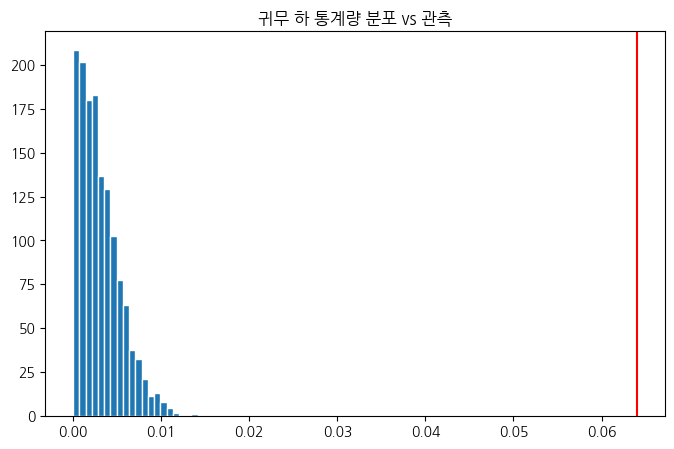

In [41]:
# TODO: 본인이 고른 (A) 또는 (B)로 작성
n_total = len(df)
p0 = 1/3
obs_stat = abs((df[CAT_COL] == 'Low').mean() - p0)
stats = np.array([])
for i in np.arange(5000):
    sim = abs(np.random.choice([1, 0], n_total, p=[p0, 1-p0]).mean() - p0)
    stats = np.append(stats, sim)
p_value = (stats >= obs_stat).mean()                             # TODO
print("관측 통계량 =", obs_stat, "| p-value =", p_value)
plt.figure(figsize=(8,5)); plt.hist(stats, bins=20, density=True, edgecolor='white')
plt.axvline(obs_stat, color='red'); plt.title("귀무 하 통계량 분포 vs 관측"); plt.show()

### 3-3. 결론 (3점)
유의수준 5%에서 결론과 근거를 서술하세요. (p-value의 의미 한 줄 포함)

**결론:** 관측된 Low 비율은 약 26.9%로, 귀무가설의 33.3%와 차이가 크다. p-value = 0.0으로,
5,000번 시뮬레이션 중 관측값만큼 극단적인 결과가 단 한 번도 나오지 않았다.
유의수준 5%보다 훨씬 작으므로 귀무가설을 강하게 기각한다.
즉, Low 위험도 직업의 비율이 1/3이라는 주장은 데이터와 맞지 않는다.
p-value는 "귀무가설이 참일 때 이 정도 이상의 극단적인 결과가 나올 확률"을 의미하며,
0에 가까울수록 귀무가설에 불리한 강력한 증거다.

---
## Task 4. 중심·산포·정규분포 — 10점

### 4-1. 평균·SD·표준단위·집중도 (6점)
`NUM_COL`의 평균·표준편차(SD)를 구하고, 표준단위 `z=(x-mean)/SD`로 변환한 뒤 **±1, ±2, ±3 SD 안에 들어오는 비율**을 계산하세요.

In [42]:
x = df[NUM_COL].dropna()
mean = x.mean(); sd = x.std();                      # TODO
z = (x - mean) / sd                                  # TODO
for k in [1,2,3]:
    within = (np.abs(z) < k).mean()                        # TODO: |z| < k 비율
    print(f"±{k} SD 안: {within:.1%}")

±1 SD 안: 61.9%
±2 SD 안: 98.4%
±3 SD 안: 100.0%


### 4-2. 정규분포 비교 (4점)
위 비율을 정규분포의 **68–95–99.7 규칙** 및 체비쇼프(어떤 분포든 ±2SD 안 ≥75%)와 비교하세요. 본인 데이터는 정규에 가까운가요?

**답변:** 이 데이터의 ±1 SD 안 비율은 61.9%, ±2 SD는 98.4%, ±3 SD는 100.0%로 나타났다.
정규분포의 68-95-99.7 규칙과 비교하면, ±1 SD는 약 6%p 낮고, ±2 SD는 약 3%p 높다. ±2 SD가 정규분포(95%)보다 높은 98.4%인 것은 극단적인 이상치가 거의 없고
데이터가 중심 근처에 안정적으로 모여 있음을 반영한다.
체비쇼프 부등식의 최소 보장치(±2 SD 안 ≥ 75%)는 훨씬 상회한다.
±1 SD가 정규분포보다 낮은 것은 분포가 약간 평평하게(균등분포에 가깝게) 퍼져 있음을 시사하며,
전반적으로 완전한 정규분포는 아니지만 크게 벗어나지도 않는 분포라고 볼 수 있다.

---
## Task 5. 표본평균의 분포와 CLT (Lec 14) — 16점

본인 데이터의 `NUM_COL` 전체를 **모집단**으로 간주합니다.

### 5-1. 모집단 모수 (3점)
모평균과 모SD를 구하세요.

In [43]:
pop = df[NUM_COL].dropna()
pop_mean = pop.mean(); pop_sd = pop.std()             # TODO
print("모평균 =", pop_mean, "| 모SD =", pop_sd)

모평균 = 46.17634733333333 | 모SD = 21.66363474002852


### 5-2. 표본평균 분포 비교 (8점)
**작은 n**과 **큰 n**(예: n과 4n, 단 4n ≤ 모집단 크기) 두 경우로 표본평균을 **2,000번**씩 구해 두 분포를 겹쳐 그리세요.

> 힌트: 함수 `sample_means(n, reps=2000)`를 만들어 재사용.

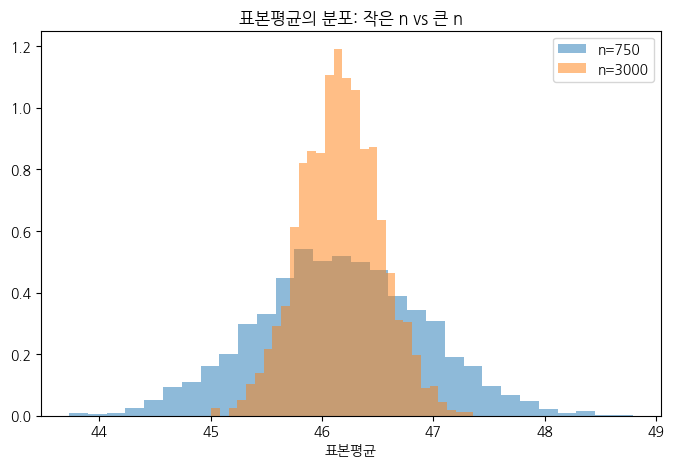

SD(작은n) = 0.7549159355248615 | SD(큰n) = 0.35563917892454083


In [44]:
def sample_means(n, reps=2000):
    means = np.array([])
    for i in np.arange(reps):
        m = pop.sample(n).mean()                          # TODO: pop에서 n개(비복원) 표본평균
        means = np.append(means, m)
    return means

n_small = max(20, len(pop)//20)
n_big   = min(len(pop), n_small*4)
mS = sample_means(n_small); mB = sample_means(n_big)
plt.figure(figsize=(8,5))
plt.hist(mS, bins=30, density=True, alpha=0.5, label=f"n={n_small}")
plt.hist(mB, bins=30, density=True, alpha=0.5, label=f"n={n_big}")
plt.legend(); plt.title("표본평균의 분포: 작은 n vs 큰 n"); plt.xlabel("표본평균"); plt.show()
print("SD(작은n) =", np.std(mS), "| SD(큰n) =", np.std(mB))

### 5-3. 제곱근 법칙 (5점)
표본평균 SD ≈ **모SD / √n** 인지 확인하고, n을 4배로 늘렸을 때 SD가 약 절반이 되는지 숫자로 보이고 해석하세요. (CLT로 표본평균 분포가 종 모양에 가까워지는지도 언급)

**답변:** 모SD = 21.66, 작은 n = 750, 큰 n = 3000일 때,
이론값: 모SD/√750 ≈ 0.791, 모SD/√3000 ≈ 0.395
실제값: SD(작은n) = 0.755, SD(큰n) = 0.356

실제값이 이론값과 매우 근접하여 표본평균 SD ≈ 모SD/√n 공식이 잘 성립함을 확인할 수 있다.
n을 4배(750→3000)로 늘렸을 때 SD가 0.755에서 0.356으로 약 절반(0.471배)으로 줄어들어
제곱근 법칙(1/√4 = 0.5)과 일치한다.
또한 히스토그램에서 큰 n일수록 분포가 더 좁고 뾰족한 종 모양에 가까워지는 것을 확인할 수 있으며,
이는 CLT(중심극한정리)에 의해 n이 커질수록 표본평균의 분포가 정규분포에 수렴함을 보여준다.

---
## Task 6. 신뢰구간 — 부트스트랩  — 14점

### 6-1. 부트스트랩 95% CI (8점)
`NUM_COL`의 **모평균**(또는 중앙값)에 대한 95% 부트스트랩 신뢰구간을 구하세요. (원표본에서 **복원추출**, 같은 크기, **3,000번**)

95% CI = [np.float64(45.84030333333334), np.float64(46.520227999999996)]


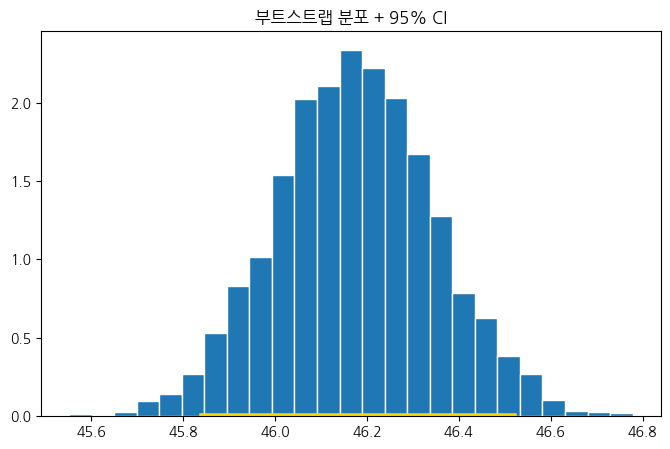

In [45]:
base = df[[NUM_COL]].dropna()
boot = np.array([])
for i in np.arange(3000):
    re = base.sample(len(base), replace=True)                             # TODO: base 복원추출(같은 크기)
    boot = np.append(boot, re[NUM_COL].mean())   # 중앙값으로 바꿔도 됨
left  = np.percentile(boot, 2.5,  method='inverted_cdf')
right = np.percentile(boot, 97.5, method='inverted_cdf')
print("95% CI =", [left, right])
plt.figure(figsize=(8,5)); plt.hist(boot, bins=25, density=True, edgecolor='white')
plt.plot([left,right],[0,0], color='gold', lw=4); plt.title("부트스트랩 분포 + 95% CI"); plt.show()

### 6-2. 해석 (6점)
- 이 CI가 의미하는 바를 본인 데이터 맥락에서 설명하세요.
- 다음 진술의 참/거짓을 판정하고 이유를 쓰세요: **"모평균이 이 구간에 있을 확률이 0.95다."**
- (선택) 어떤 특정 값이 이 CI 밖에 있는지로 간단한 가설검정을 해보세요.

**답변:** 부트스트랩 95% CI는 전체 직업의 자동화 위험도 평균이 약 [45.8%, 46.5%] 범위 안에 있을 것으로 추정함을 의미한다. / "모평균이 이 구간에 있을 확률이 0.95다"는 진술은 거짓이다. 모평균은 고정된 값이므로 확률적으로 구간 안에 있다/없다고 말할 수 없다. 올바른 해석은 "이 방법으로 구간을 반복해서 만들면 그 중 95%가 참값을 포함한다"이다. 예를 들어 "자동화 위험도 평균이 50%이다"라는 주장은 CI [45.84%, 46.52%] 밖에 있으므로
유의수준 5%에서 기각할 수 있다.

---
## Task 7. A/B 검정 · 인과 · 추정  — 20점

본인 데이터에서 **두 그룹**을 비교합니다.

### 7-0. 두 그룹 정하기
`CAT_COL`이 범주 2개면 그대로 사용하세요. 범주가 3개 이상이면 그중 **2개만** 골라 거르고, 마땅한 범주형이 없으면 아래처럼 수치형을 **중앙값 기준 두 그룹**으로 나누세요.

In [46]:
# (경우 1) CAT_COL이 이미 2범주면 그대로:
two = df[df[CAT_COL].isin(df[CAT_COL].value_counts().index[:2])].copy().reset_index(drop=True)
GROUP = CAT_COL

# (경우 2) 범주형이 없으면, 수치형을 중앙값 기준 High/Low로:
# med = df[NUM_COL2].median()
# df['__grp'] = np.where(df[NUM_COL2] >= med, 'High', 'Low')
# two = df.copy().reset_index(drop=True); GROUP = '__grp'

# ※ reset_index(drop=True): 7-1에서 라벨을 셔플해 새 컬럼에 넣을 때
#    인덱스가 0..n-1이 아니면 정렬이 어긋나 NaN이 생기는 것을 방지.
print(two[GROUP].value_counts())

automation_risk_category
Medium    6464
High      4496
Name: count, dtype: int64


### 7-1. A/B — 순열검정 (8점)
두 그룹의 `NUM_COL` **평균 차이**를 검정하세요.
- 관측 통계량 = (그룹2 평균) − (그룹1 평균)
- 그룹 라벨을 **비복원 셔플**하여 차이를 **3,000번** 시뮬레이션 → p-value.

> 힌트(수업 코드 패턴): `two[GROUP].sample(frac=1, replace=False).reset_index(drop=True)` 로 라벨만 섞기.

관측 평균차 = -26.930026618820676
p-value = 0.0


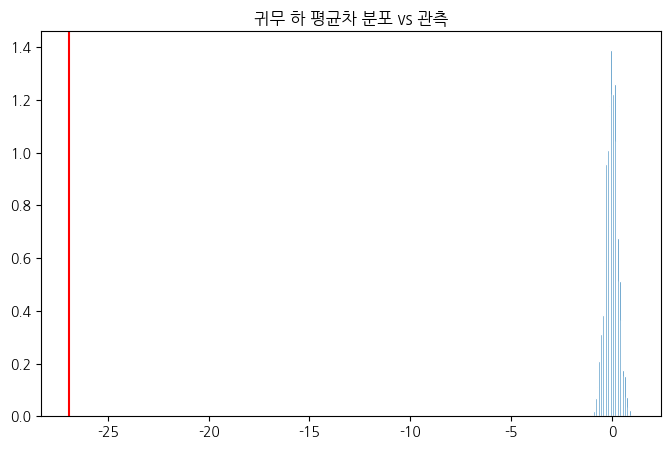

In [47]:
def diff_of_means(d, value, group):
    m = d.groupby(group)[value].mean()
    return m.iloc[1] - m.iloc[0]

observed = diff_of_means(two, NUM_COL, GROUP)                           # TODO: diff_of_means(two, NUM_COL, GROUP)
print("관측 평균차 =", observed)

diffs = np.array([])
for i in np.arange(3000):
    shuffled = two[GROUP].sample(frac=1, replace=False).reset_index(drop=True)                        # TODO: GROUP 라벨 셔플
    t = two.copy(); t['__shuf'] = shuffled
    diffs = np.append(diffs, diff_of_means(t, NUM_COL, '__shuf'))
p_ab = (np.abs(diffs) >= np.abs(observed)).mean()                               # TODO: |diffs| >= |observed| 비율 (양측) 또는 단측
print("p-value =", p_ab)
plt.figure(figsize=(8,5)); plt.hist(diffs, bins=25, density=True, edgecolor='white')
plt.axvline(observed, color='red'); plt.title("귀무 하 평균차 분포 vs 관측"); plt.show()

### 7-2. 인과 vs 상관 (6점)
- 본인 데이터는 **관찰연구**인가요, **무작위 실험(RCT)**인가요?
- 위 두 그룹 차이를 **인과(causation)** 로 해석해도 되나요, **상관(association)** 까지인가요? 왜죠?
- 영향을 줄 수 있는 **교란변수(confounder)** 를 최소 1개 제시하고, 인과를 확인하려면 어떤 실험이 필요할지 적으세요. (Lec 16: 무작위 배정의 역할)

**답변:** 순열검정 결과 관측 평균차 -26.93%p에 대해 p-value ≈ 0으로 유의수준 5%에서 귀무가설을 강하게 기각한다. 즉 Medium과 High 그룹의 자동화 위험도는 통계적으로 유의미하게 다르다.

이 데이터는 관찰연구다. 직업/산업별 자동화 위험도를 단순히 기록한 데이터이므로 연구자가 집단을 무작위로 배정하지 않았다. 따라서 Low 그룹과 High 그룹 간의 자동화 위험도 차이는 상관(association) 으로만 해석할 수 있으며 인과관계로 주장하기 어렵다. 예를 들어 직업 유형(job_role) 이 교란변수가 될 수 있다. 트럭운전사처럼 본질적으로 자동화가 쉬운 직업이 High에 몰리고 소프트웨어 엔지니어 같은 직업이 Low에 몰리기 때문에, 범주 차이가 자동화 위험도를 "결정"하는 원인이라고 볼 수 없다. 인과를 확인하려면 동일한 직무를 무작위로 두 집단에 배정하여 한쪽에는 AI 도구를 다른 쪽에는 도입하지 않는 RCT 실험이 필요하다.

### 7-3. 추정 — 그룹 통계량 부트스트랩 CI (6점)
한 그룹의 `NUM_COL` **평균(또는 중앙값)** 에 대한 95% 부트스트랩 CI를 구하고 해석하세요. (Lec 16b: 어떤 통계량이든 부트스트랩으로 추정)

In [48]:
g = two[two[GROUP] == two[GROUP].unique()[0]]   # 첫 번째 그룹
vals = g[NUM_COL].dropna()
bs = np.array([])
for i in np.arange(3000):
    re = vals.sample(len(vals), replace=True)                             # TODO: vals 복원추출
    bs = np.append(bs, re.mean())        # 중앙값: np.percentile(re,50,method='inverted_cdf')
ci = [np.percentile(bs,2.5,method='inverted_cdf'), np.percentile(bs,97.5,method='inverted_cdf')]
print("그룹 평균 95% CI =", ci)

그룹 평균 95% CI = [np.float64(44.96893873762376), np.float64(45.391212871287124)]


**해석:** 첫 번째 그룹(Medium)의 평균 자동화 위험도에 대한 95% 부트스트랩 신뢰구간은
약 [44.97%, 45.39%]로 매우 좁게 나타났다. 이는 표본 크기가 충분히 크기 때문에
추정의 불확실성이 작음을 의미한다. 즉, Medium 그룹 직업들의 모평균 자동화 위험도는
약 45% 근처에 있을 것으로 95% 신뢰 수준에서 추정할 수 있다.

---
## 제출 전 체크리스트
- [ ] `런타임 -> 모두 실행`이 **에러 없이** 끝나는가?
- [ ] 모든 `...`(TODO)를 채우고, `NUM_COL`/`CAT_COL`을 본인 데이터에 맞게 지정했는가?
- [ ] 각 Task의 **해석/답변 마크다운**을 작성했는가?
- [ ] 파일명을 `IDS_HW2_학번_이름(한국이름).ipynb` 로 바꿔 Plato에 제출했는가?

**마감: 2026-06-26 (금)**  